1. TITLE:-
# Netflix Content Analysis and Clustering Using Machine Learning

2. OBJECTIVE:-
## Objective:-

-> The main goal of this project is to explore and analyze the Netflix movies and TV shows dataset to understand patterns in content distribution, production trends, and audience targeting.

-> In addition to exploratory data analysis, machine learning techniques are applied to group similar content using clustering methods. This helps in identifying hidden relationships within the dataset and provides insights that can be useful for recommendation systems and content strategy.

3. DATASET DESCRIPTION:-
## Dataset Description:-

-> The dataset used in this project contains detailed information about movies and TV shows available on Netflix. Each record represents a piece of content along with its attributes such as title, type, release year, country, rating, duration, and genre.

-> This dataset enables analysis of how Netflix content varies across different regions, categories, and time periods, and helps in identifying trends in the streaming platform’s content library.

4. DATA DICTIONARY:-
## Data Dictionary:-

-> show_id: A unique identifier assigned to each content item
-> type: Specifies whether the content is a Movie or a TV Show
-> title: Name of the movie or TV show
-> director: Name of the director
-> cast: List of actors involved in the content
-> country: Country where the content was produced
-> date_added: Date when the content was added to Netflix
-> release_year: Year in which the content was originally released
-> rating: Age rating of the content (e.g., TV-MA, PG-13)
-> duration: Length of the movie (in minutes) or number of seasons for TV shows
-> listed_in: Categories or genres associated with the content
-> description: Short summary of the content

5. TOOLS AND TECHNOLOGIES USED:-
## Tools and Technologies Used:-

-> Python for data analysis and modeling  
-> Pandas for data manipulation  
-> NumPy for numerical operations  
-> Matplotlib and Seaborn for data visualization  
-> Scikit-learn for machine learning algorithms such as PCA and K-Means clustering

In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

data = pd.read_csv("../data/netflix.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [8]:
data.shape

(7787, 12)

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


In [10]:
data.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [11]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [12]:
data.fillna(data.mode().iloc[0], inplace=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,"Raúl Campos, Jan Suter","João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,"Raúl Campos, Jan Suter",Nasty C,United States,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,"Raúl Campos, Jan Suter","Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [13]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [20]:
import matplotlib.pyplot as plt

In [21]:
# Function to plot top values of any categorical column
def plot_top_categories(data, column, title, top_n=10):
    counts = data[column].value_counts().head(top_n)
    
    plt.figure(figsize=(8,5))
    counts.plot(kind='bar')
    
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

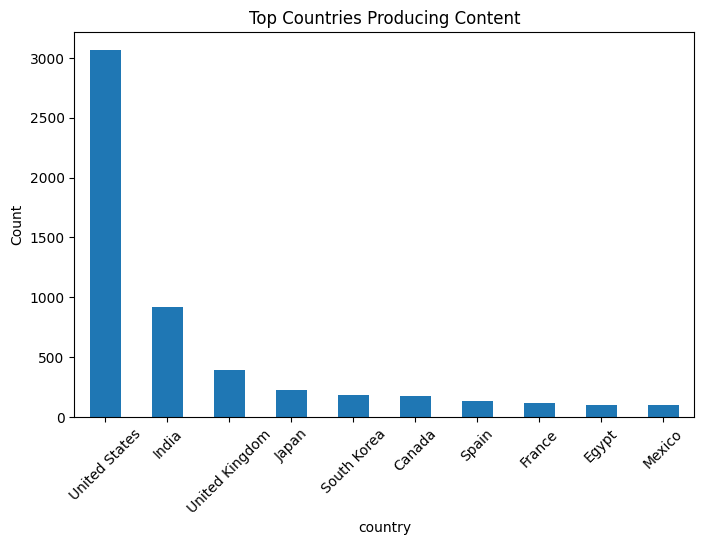

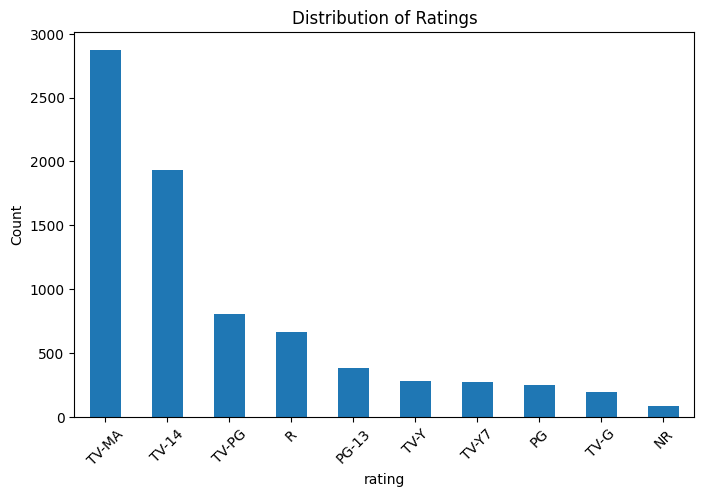

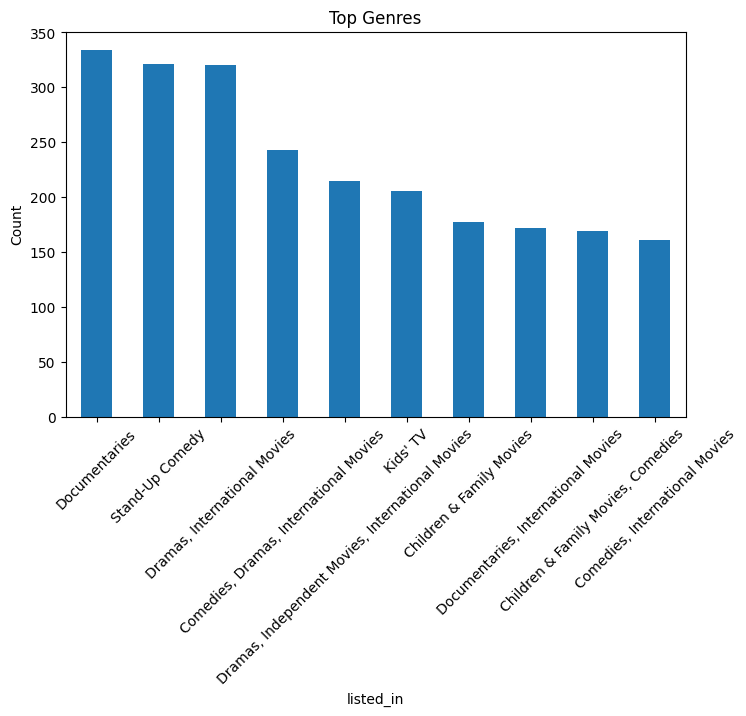

In [22]:
# Top countries
plot_top_categories(data, 'country', "Top Countries Producing Content")

# Top ratings
plot_top_categories(data, 'rating', "Distribution of Ratings")

# Top genres (advanced use)
plot_top_categories(data, 'listed_in', "Top Genres")

In [23]:
from sklearn.cluster import KMeans

In [24]:
# Function to perform clustering and return labels
def apply_kmeans(data, n_clusters):
    model = KMeans(n_clusters=n_clusters, random_state=42)
    return model.fit_predict(data)

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

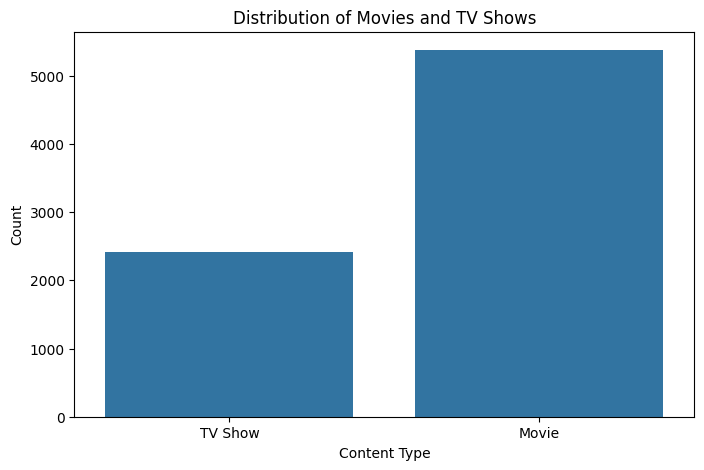

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(x='type', data=data)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

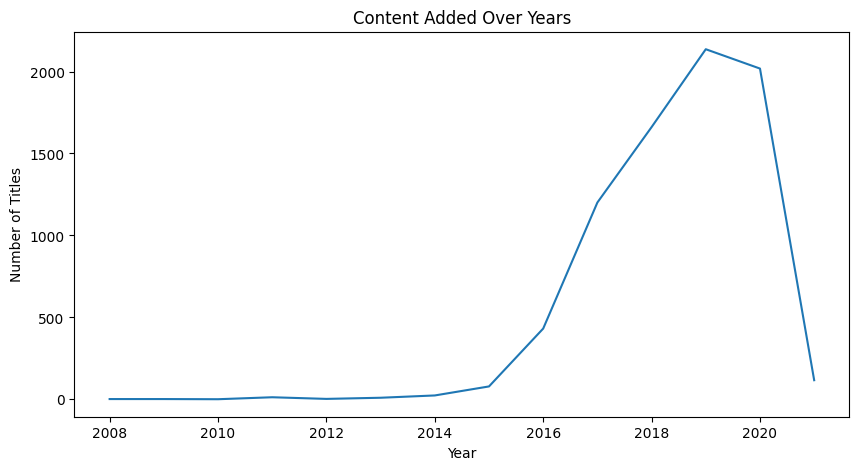

In [27]:
plt.figure(figsize=(10,5))

data['year_added'].value_counts().sort_index().plot()

plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

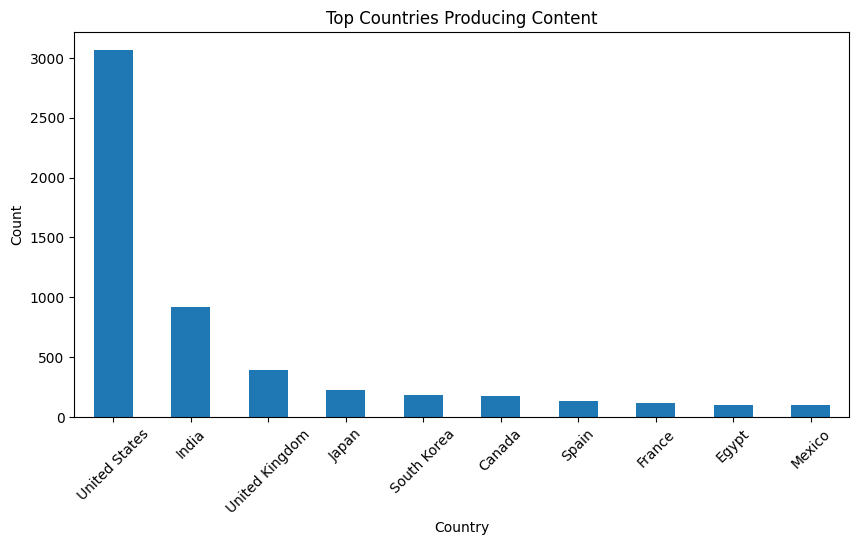

In [28]:
plt.figure(figsize=(10,5))

data['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

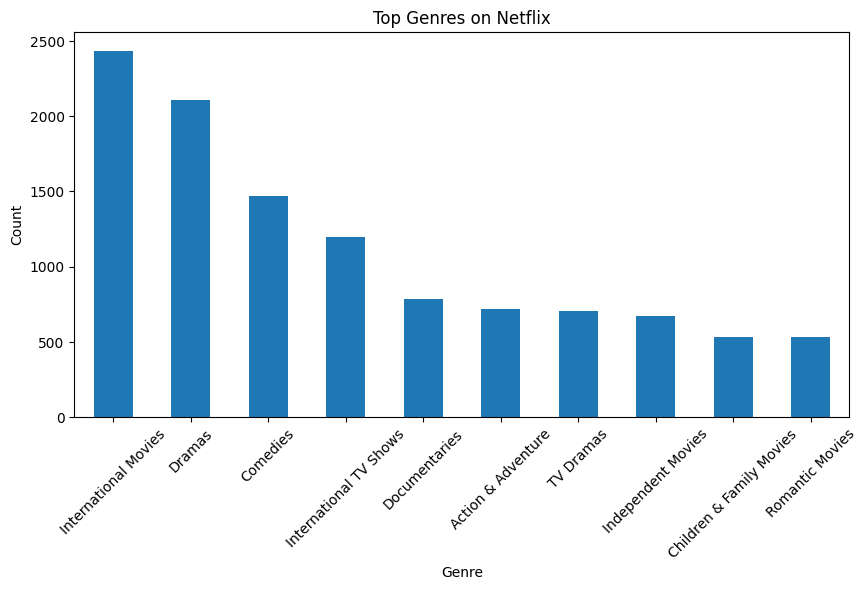

In [29]:
plt.figure(figsize=(10,5))

data['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

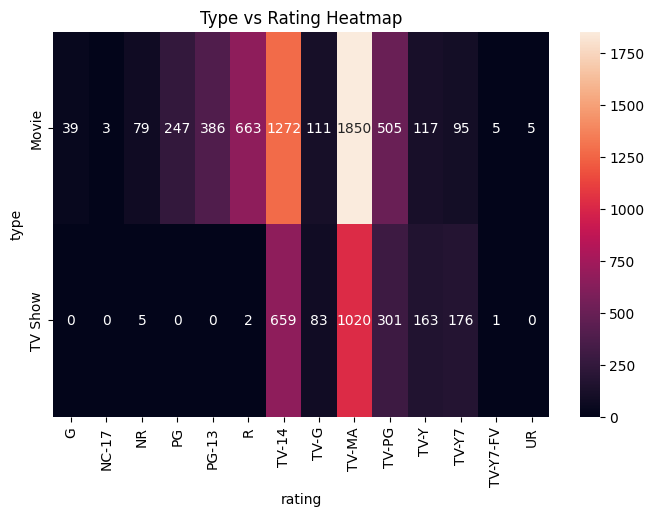

In [30]:
plt.figure(figsize=(8,5))

pivot = pd.crosstab(data['type'], data['rating'])

sns.heatmap(pivot, annot=True, fmt='d')

plt.title("Type vs Rating Heatmap")

plt.show()

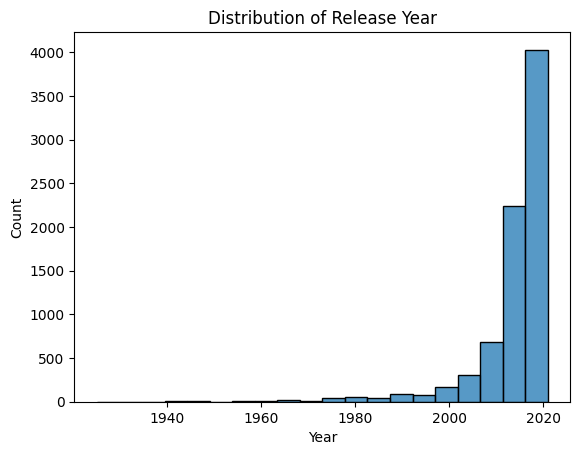

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data['release_year'], bins=20)

plt.title("Distribution of Release Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

# Movies dominate the dataset
# Content production has grown over time
# A few countries contribute most content
# Genres and ratings show clear patterns
# Netflix content is diverse bit follow trends